In [1]:
import pandas as pd
import numpy as np
import re
import geopandas as gpd 

fp = "/Users/abrahamsadat/Downloads/Demographic Data Cook County Public Schools (SY 24-25).csv"
df = pd.read_csv(fp, low_memory=False)

# -----------------------------
# 1) School-level only
# -----------------------------
df = df[df["Level"].eq("School")].copy()

# -----------------------------
# 2) High schools only (STRICT)
#    - keep rows where School Type == "High School"
# -----------------------------
df["School Type"] = df["School Type"].astype(str).str.strip()
df = df[df["School Type"].eq("High School")].copy()

# -----------------------------
# 3) Keep ID columns
# -----------------------------
id_cols = [
    "RCDTS", "School Name", "District", "City", "County",
    "District Type", "School Type", "Grades Served"
]
id_cols = [c for c in id_cols if c in df.columns]

# -----------------------------
# 4) Choose demographic percent columns:
#    - must start with "% "
#    - must include "Enrollment" OR known demographic labels
#    - must NOT include outcome-y stuff like "Accelerated"
# -----------------------------
include_pat = re.compile(
    r"(Enrollment|LowIncome|FRL|Free|Reduced|IEP|CWD|Disab|504|EL|ELL|English Learner|Homeless|Foster|MENA|Two or More|White|Black|Hispanic|Latino|Asian|Pacific|Hawaiian|American Indian|Alaska)",
    flags=re.IGNORECASE
)
exclude_pat = re.compile(
    r"(Accelerated|Achievement|Growth|Proficiency|Score|Chronic|Attendance|Suspension|Discipline|Graduation|Assessment)",
    flags=re.IGNORECASE
)

pct_cols = [c for c in df.columns if str(c).startswith("%")]

demo_cols = [
    c for c in pct_cols
    if include_pat.search(c) and not exclude_pat.search(c)
]

# -----------------------------
# 5) Build + clean
# -----------------------------
hs_demo = df[id_cols + demo_cols].copy()

hs_demo = hs_demo.replace({"*": np.nan, "": np.nan, "N/A": np.nan})
hs_demo[demo_cols] = hs_demo[demo_cols].apply(pd.to_numeric, errors="coerce")

# If the file stores proportions (0-1), convert to percent
vals = hs_demo[demo_cols].stack().dropna()
if len(vals) and vals.quantile(0.95) <= 1:
    hs_demo[demo_cols] *= 100

# sanity check: should contain only high schools
print(hs_demo["School Type"].value_counts(dropna=False))

hs_demo.head()


/var/folders/5k/2ty13j0s5y70zwdnmbbzwh_r0000gn/T/ipykernel_2033/1169496291.py:57: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  hs_demo = hs_demo.replace({"*": np.nan, "": np.nan, "N/A": np.nan})


School Type
High School    696
Name: count, dtype: int64


,RCDTS,School Name,District,City,County,District Type,School Type,Grades Served,% Student Enrollment -Male,% Student Enrollment - Female,...,% Students Identified as Gifted Taught by Gifted-endorsed Teachers - White,% Students Identified as Gifted Taught by Gifted-endorsed Teachers - Black or African American,% Students Identified as Gifted Taught by Gifted-endorsed Teachers - Hispanic or Latino,% Students Identified as Gifted Taught by Gifted-endorsed Teachers - Asian,% Students Identified as Gifted Taught by Gifted-endorsed Teachers - Native Hawaiian or Other Pacific Islander,% Students Identified as Gifted Taught by Gifted-endorsed Teachers - American Indian or Alaska Native,% Students Identified as Gifted Taught by Gifted-endorsed Teachers - Two or More Race,% Students Identified as Gifted Taught by Gifted-endorsed Teachers - MENA,% Students Identified as Gifted Taught by Gifted-endorsed Teachers - IEP,% Students Identified as Gifted Taught by Gifted-endorsed Teachers - EL
3,01-009-2620-26-0002,A-C Central High School,A-C Central CUSD 262,Ashland,Cass,Unit District,High School,9 - 12,51.1,48.9,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,33-048-2760-26-0001,Abingdon-Avon High Sch,Abingdon-Avon CUSD 276,Abingdon,Knox,Unit District,High School,9 - 12,50.4,49.6,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
23,34-049-1250-13-0001,Adlai E Stevenson High School,Adlai E Stevenson HSD 125,Lincolnshire,Lake,High School District,High School,9 - 12,51.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
30,44-063-0190-24-0002,Alden-Hebron High School,Alden Hebron SD 19,Hebron,McHenry,Unit District,High School,9 - 12,56.0,44.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
44,03-025-0100-26-0001,Altamont High School,Altamont CUSD 10,Altamont,Effingham,Unit District,High School,9 - 12,48.4,51.6,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [2]:
filepath = "/Users/abrahamsadat/Downloads/SABS_1516_SchoolLevels/SABS_1516_High.shp"
hs_shapefiles = gpd.read_file(filepath)
illinois_hs_shapefiles = hs_shapefiles[hs_shapefiles['stAbbrev'] == 'IL']
illinois_hs_shapefiles['schnam'].unique()


array(['River Ridge High School', 'Casey-Westfield Jr/Sr HS',
       'Blue Ridge High School', 'Norris City-Omaha-Enfield H S',
       'Eastland Jr/Sr High School', 'Goreville High School',
       'Joppa Jr & Sr High School', 'GCMS High School',
       'Farmington Central High Sch', 'Gallatin High School',
       'Georgetown-Ridge Farm High School', 'Brussels High School',
       'A-C Central High School', 'Heritage High School',
       'Ridgeview High School', 'Illini Central High School',
       'South Central High School', 'Henry-Senachwine High School',
       'Meridian High School', 'Bureau Valley High School',
       'Midland High School', 'Lewistown High School', 'Christopher High',
       'Okaw Valley High School', 'West Carroll High School',
       'West Prairie High School', 'West Central High School',
       'Monmouth-Roseville High Sch', 'United High School',
       'Sangamon Valley High School', 'Rushville-Industry High School',
       'Thompsonville High School', 'Illini 

In [3]:
school_name_map = {

    # Exact or near-exact matches
    "Dundee-Crown High School": "Dundee-Crown High School",
    "Hampshire High School": "Hampshire High School",
    "Jacobs High School": "Harry D Jacobs High School",
    "Barrington High School": "Barrington High School",

    "AMUNDSEN HS": "Amundsen High School",
    "BOGAN HS": "Bogan High School",
    "BOWEN HS": "Bowen High School",
    "FENGER HS": "Fenger Academy High School",
    "FOREMAN HS": "Foreman High School",
    "HARLAN HS": "Harlan Community Academy HS",
    "HIRSCH HS": "Hirsch Metropolitan High School",
    "HYDE PARK HS": "Hyde Park Academy High School",
    "KELVYN PARK HS": "Kelvyn Park High School",
    "KENNEDY HS": "Kennedy High School",
    "MANLEY HS": "Manley Career Academy High School",
    "MATHER HS": "Mather High School",
    "MORGAN PARK HS": "Morgan Park High School",
    "ROOSEVELT HS": "Roosevelt High School",
    "SCHURZ HS": "Schurz High School",
    "SENN HS": "Senn High School",
    "STEINMETZ HS": "Steinmetz College Prep HS",
    "SULLIVAN HS": "Sullivan High School",
    "TAFT HS": "Taft High School",
    "LINCOLN PARK HS": "Lincoln Park High School",
    "WASHINGTON HS": "Washington G High School",
    "WELLS HS": "Wells Community Academy HS",
    "KENWOOD HS": "Kenwood Academy High School",
    "CLEMENTE HS": "Clemente Community Academy HS",
    "CORLISS HS": "Corliss High School",
    "JULIAN HS": "Julian High School",
    "JUAREZ HS": "Juarez Community Academy HS",
    "KELLY HS": "Kelly High School",
    "RICHARDS HS": "H L Richards High Sch(Campus)",
    "ORR HS": "Orr Academy High School",
    "FARRAGUT HS": "Farragut Career Academy HS",
    "INFINITY HS": "Infinity Math  Science & Tech HS",
    "GAGE PARK HS": "Gage Park High School",
    "HUBBARD HS": "Hubbard High School",
    "SOLORIO HS": "Solorio Academy High School",
    "CHICAGO VOCATIONAL HS": "Chicago Vocational Career Acad HS",
    "LAKE VIEW HS": "Lake View High School",
    "PHILLIPS HS": "Phillips Academy High School",
    "DYETT ARTS HS": "Dyett High School",
    "CURIE HS": "Curie Metropolitan High School",
    "TILDEN HS": "Tilden Career Communty Academy HS",
    "ENGLEWOOD STEM HS": "Team Englewood Comm Acad HS",
    "NORTH-GRAND HS": "North-Grand High School",
    "AUSTIN CCA HS": "Austin Bus & Entrepreneurship HS",

    "Elmwood Park HS": "Elmwood Park High School",
    "Bartlett High School": "Bartlett High School",
    "Elgin High School": "Elgin High School",
    "Larkin High School": "Larkin High School",
    "South Elgin High School": "South Elgin High School",
    "Streamwood High School": "Streamwood High School",

    "Argo Community High School": "Argo Community High School",
    "Bloom High School": "Bloom High School",
    "Bloom Trail High School": "Bloom Trail High School",
    "Bremen High School": "Bremen High School",
    "Tinley Park High School": "Tinley Park High School",
    "Hillcrest High School": "Hillcrest High School",
    "Oak Forest High School": "Oak Forest High School",
    "Eisenhower High School": "DD Eisenhower High Sch (Campus)",
    "Shepard High School": "A B Shepard High Sch (Campus)",

    "Andrew High": "Victor J Andrew High School",
    "Sandburg High": "Carl Sandburg High School",
    "Stagg High": "Amos Alonzo Stagg High School",

    "Evanston Township High School": "Evanston Twp High School",
    "Evergreen Park Community High School": "Evergreen Park High School",

    "Hinsdale Central High School": "Hinsdale Central High School",
    "Hinsdale South High School": "Hinsdale South High School",
    "Homewood-Flossmoor High School": "Homewood-Flossmoor High School",
    "Lemont High School": "Lemont Twp High School",

    "East Leyden High School": "East Leyden High School",
    "West Leyden High School": "West Leyden High School",

    "Lyons Township High Sch": "Lyons Twp High Sch",

    "Maine East High School": "Maine East High School",
    "Maine West High School": "Maine West High School",
    "Maine South High School": "Maine South High School",

    "J. Sterling Morton East High Sch": "J Sterling Morton East High Sch",
    "J. Sterling Morton West High Sch": "J Sterling Morton West High Sch",

    "New Trier High School": "New Trier Township H S Winnetka",

    "Niles North High School": "Niles North High School",
    "Niles Central": "Niles Central",
    "Niles West High School": "Niles West High School",

    "Glenbrook North High School": "Glenbrook North High School",
    "Glenbrook South High School": "Glenbrook South High School",

    "Oak Lawn Comm High School": "Oak Lawn Comm High School",
    "Oak Park & River Forest High Sch": "Oak Park & River Forest High Sch",

    "Proviso West High School": "Proviso West High School",
    "Proviso East High School": "Proviso East High School",

    "Ridgewood Comm High School": "Ridgewood Comm High School",
    "Riverside Brookfield Twp HS": "Riverside Brookfield Twp HS",

    "Thornton Fractnl No High School": "Thornton Fractnl No High School",
    "Thornton Fractnl So High School": "Thornton Fractnl So High School",
    "Thornton Township High School": "Thornton Township High School",
    "Thornridge High School": "Thornridge High School",
    "Thornwood High School": "Thornwood High School",

    "Conant High School": "J B Conant High School",
    "Fremd High School": "Wm Fremd High School",
    "Hoffman Estates High School": "Hoffman Estates High School",
    "Palatine High School": "Palatine High School",
    "Schaumburg High School": "Schaumburg High School",

    "Buffalo Grove High School": "Buffalo Grove High School",
    "Elk Grove High School": "Elk Grove High School",
    "John Hersey High School": "John Hersey High School",
    "Prospect High School": "Prospect High School",
    "Rolling Meadows High School": "Rolling Meadows High School",
    "Wheeling High School": "Wheeling High School"
}

In [4]:
matched_names = list(school_name_map.values())

filtered_df = illinois_hs_shapefiles[illinois_hs_shapefiles["schnam"].isin(matched_names)]
filtered_df.head()

,SrcName,ncessch,schnam,leaid,gslo,gshi,defacto,stAbbrev,openEnroll,Shape_Leng,Shape_Area,level,MultiBdy,geometry
3179,None,170402000088,Argo Community High School,1704020,09,12,1,IL,0,36929.226449,5.690731e+07,3,0,"POLYGON ((-9783468.718 5120879.539, -9783423.9..."
3181,Buffalo Grove High School,170417000110,Buffalo Grove High School,1704170,09,12,0,IL,0,28845.960480,3.733350e+07,3,0,"POLYGON ((-9796178.852 5184023.161, -9796070.4..."
3182,Elk Grove High School,170417000111,Elk Grove High School,1704170,09,12,0,IL,0,48525.268420,8.824971e+07,3,0,"POLYGON ((-9796846.1 5168648.575, -9796704.469..."
3183,John Hersey High School,170417000113,John Hersey High School,1704170,09,12,0,IL,0,48847.376944,4.536811e+07,3,0,"POLYGON ((-9783655.516 5175195.251, -9783655.5..."
3184,Prospect High School,170417000114,Prospect High School,1704170,09,12,0,IL,0,31911.050706,3.713365e+07,3,0,"POLYGON ((-9787280.564 5170899.517, -9787282.0..."


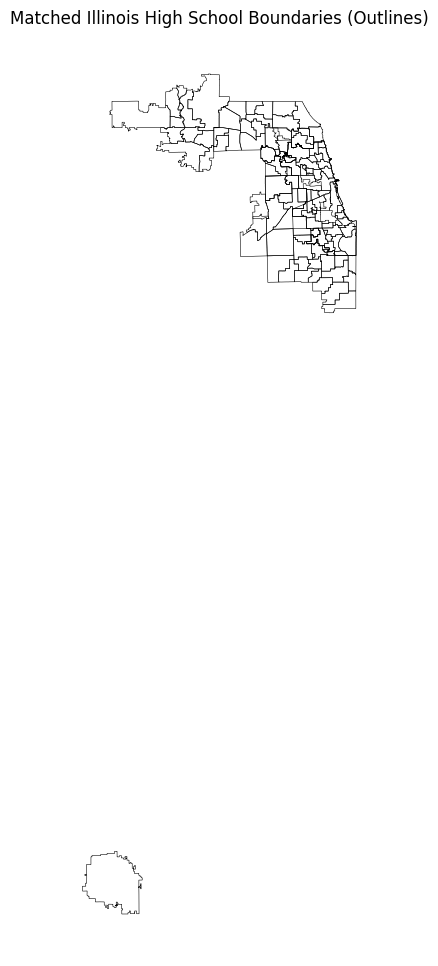

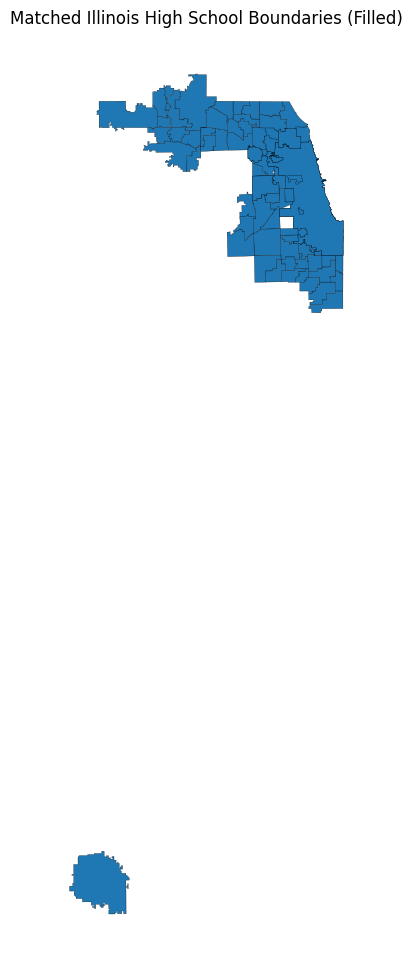

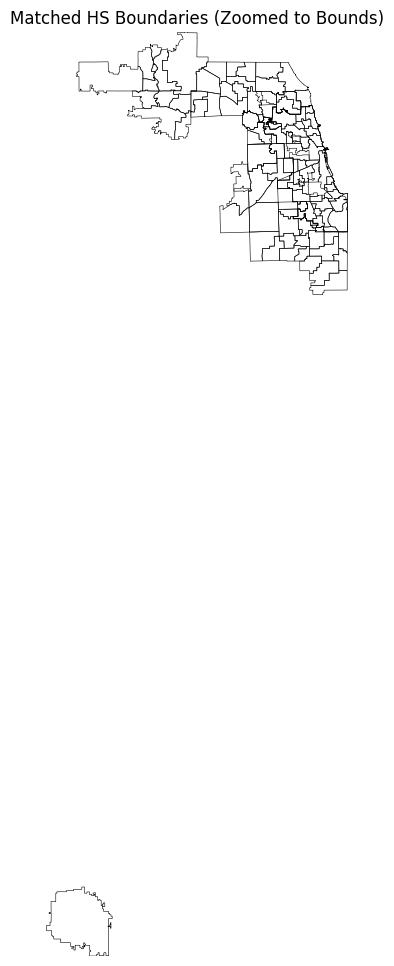

In [5]:
# Plot matched Illinois high school boundary polygons (sanity-check geometry first)

import geopandas as gpd
import matplotlib.pyplot as plt

# --- 1) Filter to matched school names ---
matched_names = list(school_name_map.values())

filtered_df = illinois_hs_shapefiles[
    illinois_hs_shapefiles["schnam"].isin(matched_names)
].copy()

# --- 2) Ensure it's a GeoDataFrame with a geometry column ---
gdf = gpd.GeoDataFrame(filtered_df, geometry="geometry")

# --- 3) Make CRS sane (common for NCES boundaries: EPSG:3857 Web Mercator) ---
# If gdf already has a CRS, we keep it. If not, we assign 3857 and convert to 4326 for display.
if gdf.crs is None:
    gdf = gdf.set_crs(epsg=3857)

# Convert to lat/long for nicer plotting (optional, but usually helpful)
gdf_plot = gdf.to_crs(epsg=4326)

# --- 4) Plot outlines (no fill) ---
fig, ax = plt.subplots(figsize=(12, 12))
gdf_plot.plot(
    ax=ax,
    edgecolor="black",
    facecolor="none",
    linewidth=0.4
)
ax.set_title("Matched Illinois High School Boundaries (Outlines)")
ax.axis("off")
plt.show()

# --- 5) Plot filled (quick geometry integrity check) ---
fig, ax = plt.subplots(figsize=(12, 12))
gdf_plot.plot(
    ax=ax,
    edgecolor="black",
    linewidth=0.2
)
ax.set_title("Matched Illinois High School Boundaries (Filled)")
ax.axis("off")
plt.show()

#  6) Optional: zoom to a bounding box (uncomment + tweak) ---
minx, miny, maxx, maxy = gdf_plot.total_bounds
fig, ax = plt.subplots(figsize=(12, 12))
gdf_plot.plot(ax=ax, edgecolor="black", facecolor="none", linewidth=0.4)
ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)
ax.set_title("Matched HS Boundaries (Zoomed to Bounds)")
ax.axis("off")
plt.show()

In [6]:
census_data = pd.read_csv("/Users/abrahamsadat/Downloads/cook_tract_income_v7_2016_2024.csv")
census_data.head()

,GEOID,median_hh_income,total_n_hh,hh_under_0.5_pov,hh_between_0.5_0.74_pov,hh_between_0.75_0.99_pov,hh_between_1.00_to_1.24_pov,hh_between_1.25_to_1.49_pov,hh_between_1.50_to_1.74_pov,hh_between_1.75_to_1.84_pov,hh_between_1.85_to_1.99_pov,hh_between_2.00_to_2.99_pov,hh_between_3.00_to_3.99_pov,hh_between_4.00_to_4.99_pov,hh_between_5.00_and_over_pov,year,pov_share_under_1_00
0,17031806002,56975,1855,187,72,86,35,35,69,16,27,386,296,266,380,2016,0.185984
1,17031806003,53769,1836,32,39,6,35,55,108,0,55,311,560,285,350,2016,0.041939
2,17031806400,62750,605,49,0,31,0,12,17,11,35,47,40,104,259,2016,0.132231
3,17031806501,53583,601,55,31,6,24,23,50,21,22,120,95,65,89,2016,0.153078
4,17031750600,40125,717,58,66,72,10,35,0,0,0,103,201,23,149,2016,0.273361


In [7]:
#Load census tract geometries and prepare id column data for mapping
census_gdf = gpd.read_file("/Users/abrahamsadat/My Drive/CoffeeCoders/data/cook_county/PVS_25_v2_tracts2020_17031.shp")
census_gdf = census_gdf.rename(columns={'TRACTID': 'GEOID'})
census_gdf['GEOID'] = census_gdf['GEOID'].astype(int)
census_gdf = census_gdf.rename(columns={"TRACTID": "GEOID"})
census_gdf["GEOID"] = census_gdf["GEOID"].astype(str)
census_data["GEOID"] = census_data["GEOID"].astype(str)

#Create the map
geoid_to_geom = census_gdf.set_index("GEOID")["geometry"]

#Map
census_data["geometry"] = census_data["GEOID"].map(geoid_to_geom)

#Convert census_data to gpd file:
census_data_cleaned = gpd.GeoDataFrame(
    census_data,
    geometry="geometry",
    crs=gdf.crs   # inherit CRS from tract shapefile
)

In [10]:
#Set crs to be the same thing in both schools and census tracts:
AREA_CRS = "EPSG:3435"
filtered_df.to_crs(AREA_CRS)
census_data_cleaned.to_crs(AREA_CRS)

#Compute area tract areas (denominator of weights):
census_data_cleaned['tract_area'] = census_data_cleaned.geometry.area
census_data_cleaned.head()


,GEOID,median_hh_income,total_n_hh,hh_under_0.5_pov,hh_between_0.5_0.74_pov,hh_between_0.75_0.99_pov,hh_between_1.00_to_1.24_pov,hh_between_1.25_to_1.49_pov,hh_between_1.50_to_1.74_pov,hh_between_1.75_to_1.84_pov,hh_between_1.85_to_1.99_pov,hh_between_2.00_to_2.99_pov,hh_between_3.00_to_3.99_pov,hh_between_4.00_to_4.99_pov,hh_between_5.00_and_over_pov,year,pov_share_under_1_00,geometry,tract_area
0,17031806002,56975,1855,187,72,86,35,35,69,16,27,386,296,266,380,2016,0.185984,"POLYGON ((-87.887 42.054, -87.887 42.054, -87....",0.000267
1,17031806003,53769,1836,32,39,6,35,55,108,0,55,311,560,285,350,2016,0.041939,None,NaN
2,17031806400,62750,605,49,0,31,0,12,17,11,35,47,40,104,259,2016,0.132231,"POLYGON ((-87.893 42.032, -87.893 42.032, -87....",0.000127
3,17031806501,53583,601,55,31,6,24,23,50,21,22,120,95,65,89,2016,0.153078,"POLYGON ((-87.894 42.024, -87.894 42.024, -87....",0.000091
4,17031750600,40125,717,58,66,72,10,35,0,0,0,103,201,23,149,2016,0.273361,"POLYGON ((-87.663 41.69, -87.663 41.69, -87.66...",0.000142


In [ ]:
census_data_cleaned["tract_area"] = census_data_cleaned.geometry.area


In [16]:
from shapely.geometry import Polygon
intersections = census_data_cleaned['geometry'].intersection(filtered_df['geometry'])
print(intersections)

0        None
1        None
2        None
3        None
4        None
         ... 
11931    None
11932    None
11933    None
11934    None
11935    None
Length: 11936, dtype: geometry


/var/folders/5k/2ty13j0s5y70zwdnmbbzwh_r0000gn/T/ipykernel_2033/1501976054.py:2: UserWarning: The indices of the left and right GeoSeries' are not equal, and therefore they will be aligned (reordering and/or introducing missing values) before executing the operation. If this alignment is the desired behaviour, you can silence this warning by passing 'align=True'. If you don't want alignment and protect yourself of accidentally aligning, you can pass 'align=False'.
  intersections = census_data_cleaned['geometry'].intersection(filtered_df['geometry'])


In [18]:
# Fix invalid geometries (prevents overlay crashes / weird results)
census_data_cleaned["geometry"] = census_data_cleaned.geometry.make_valid()
filtered_df["geometry"] = filtered_df.geometry.make_valid()

pieces = gpd.overlay(census_data_cleaned, filtered_df, how="intersection", keep_geom_type=False)

In [21]:
import geopandas as gpd

# -------------------------
# 0) Define CRS for area/intersection
# -------------------------
AREA_CRS = "EPSG:3435"  # Illinois East (ftUS)

# -------------------------
# 1) Build a proper TRACTS GeoDataFrame (one row per GEOID)
#    (Avoid duplicating tracts across years during overlay)
# -------------------------
tracts = census_data_cleaned.copy()

# keep just the columns you want carried through
tract_keep = ["GEOID", "median_hh_income", "pov_share_under_1_00"]  # edit to your variables
tract_keep = [c for c in tract_keep if c in tracts.columns]         # safe if some cols missing
tracts = tracts[tract_keep + ["geometry"]].copy()

# IMPORTANT: one geometry per tract
tracts = tracts.dropna(subset=["geometry"]).drop_duplicates(subset=["GEOID"]).copy()

# -------------------------
# 2) Prep SCHOOLS GeoDataFrame
# -------------------------
schools = filtered_df.copy()

# choose / create a school_id column
# (edit these candidates based on what your df actually has)
for cand in ["school_id", "ncessch", "RCDTS", "schnam", "School Name"]:
    if cand in schools.columns:
        schools = schools.rename(columns={cand: "school_id"})
        break

# keep only id + geometry
schools = schools[["school_id", "geometry"]].dropna(subset=["geometry"]).copy()

# -------------------------
# 3) Project both to the SAME area CRS + fix invalids
# -------------------------
tracts = tracts.to_crs(AREA_CRS)
schools = schools.to_crs(AREA_CRS)

tracts["geometry"] = tracts.geometry.make_valid()
schools["geometry"] = schools.geometry.make_valid()

assert tracts.crs == schools.crs

# -------------------------
# 4) Overlay intersection (the main step)
# -------------------------
pieces = gpd.overlay(tracts, schools, how="intersection", keep_geom_type=False)

# -------------------------
# 5) Checkpoints
# -------------------------
print("tracts:", len(tracts))
print("schools:", len(schools))
print("pieces:", len(pieces))
print("pieces columns:", pieces.columns.tolist())

# If this is 0, it's CRS mismatch or non-overlap
assert len(pieces) > 0

# -------------------------
# 6) (Optional but usually needed) compute fragment area + tract area + weights
# -------------------------
pieces["piece_area"] = pieces.geometry.area

tracts_area = tracts[["GEOID", "geometry"]].copy()
tracts_area["tract_area"] = tracts_area.geometry.area
tracts_area = tracts_area.drop(columns=["geometry"])

pieces = pieces.merge(tracts_area, on="GEOID", how="left")
pieces["weight"] = pieces["piece_area"] / pieces["tract_area"]

# sanity: weights per tract should sum ~1
print(pieces.groupby("GEOID")["weight"].sum().describe())

tracts: 1332
schools: 108
pieces: 0
pieces columns: ['GEOID', 'median_hh_income', 'pov_share_under_1_00', 'school_id', 'geometry']


/opt/miniconda3/envs/new_dap/lib/python3.12/site-packages/shapely/constructive.py:752: RuntimeWarning: invalid value encountered in make_valid
  return lib.make_valid(geometry, **kwargs)


AssertionError: 

In [22]:
import geopandas as gpd

AREA_CRS = "EPSG:3435"

# --- 1) basic counts + geometry health BEFORE reprojection
print("TRACTS raw rows:", len(census_data_cleaned))
print("SCHOOLS raw rows:", len(filtered_df))

print("TRACTS missing geom:", census_data_cleaned.geometry.isna().sum())
print("SCHOOLS missing geom:", filtered_df.geometry.isna().sum())

print("TRACTS crs:", census_data_cleaned.crs)
print("SCHOOLS crs:", filtered_df.crs)

# --- 2) make overlay inputs (one row per tract GEOID)
tracts = census_data_cleaned.dropna(subset=["geometry"]).drop_duplicates("GEOID")[["GEOID", "geometry"]].copy()
schools = filtered_df.dropna(subset=["geometry"]).copy()

# make sure schools are polygons (overlay intersection expects polygons)
print("\nSCHOOLS geom types (raw):")
print(schools.geom_type.value_counts().head(10))

# --- 3) bounds BEFORE reprojection (these should look like lon/lat ~ [-88,-87,41,42] if CRS is geographic)
print("\nTRACTS bounds (raw):", tracts.total_bounds)
print("SCHOOLS bounds (raw):", schools.total_bounds)

# --- 4) reproject + bounds AFTER reprojection (these should be big Illinois-foot numbers in EPSG:3435)
tracts_p = tracts.to_crs(AREA_CRS)
schools_p = schools.to_crs(AREA_CRS)

tracts_p["geometry"] = tracts_p.geometry.make_valid()
schools_p["geometry"] = schools_p.geometry.make_valid()

print("\nTRACTS bounds (3435):", tracts_p.total_bounds)
print("SCHOOLS bounds (3435):", schools_p.total_bounds)

# --- 5) quick overlap test using bounding boxes
tracts_box = tracts_p.unary_union.envelope
schools_box = schools_p.unary_union.envelope
print("\nDo bounding boxes intersect?:", tracts_box.intersects(schools_box))

# --- 6) spatial join test (faster / simpler than overlay) to see if ANY overlap exists
# use intersects (not within) because both are polygons
sj = gpd.sjoin(tracts_p, schools_p[["geometry"]], how="inner", predicate="intersects")
print("Spatial join matches:", len(sj))

TRACTS raw rows: 11936
SCHOOLS raw rows: 108
TRACTS missing geom: 124
SCHOOLS missing geom: 0
TRACTS crs: EPSG:3857
SCHOOLS crs: EPSG:3857

SCHOOLS geom types (raw):
Polygon         96
MultiPolygon    12
Name: count, dtype: int64

TRACTS bounds (raw): [-88.263641  41.469705 -87.111162  42.154292]
SCHOOLS bounds (raw): [-9875965.2004  4789790.0788 -9743090.0101  5197546.1259]


/opt/miniconda3/envs/new_dap/lib/python3.12/site-packages/shapely/constructive.py:752: RuntimeWarning: invalid value encountered in make_valid
  return lib.make_valid(geometry, **kwargs)
/var/folders/5k/2ty13j0s5y70zwdnmbbzwh_r0000gn/T/ipykernel_2033/1283267563.py:38: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  tracts_box = tracts_p.unary_union.envelope
/opt/miniconda3/envs/new_dap/lib/python3.12/site-packages/shapely/set_operations.py:553: RuntimeWarning: invalid value encountered in unary_union
  return lib.unary_union(collections, **kwargs)
/var/folders/5k/2ty13j0s5y70zwdnmbbzwh_r0000gn/T/ipykernel_2033/1283267563.py:39: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  schools_box = schools_p.unary_union.envelope



TRACTS bounds (3435): [inf inf inf inf]
SCHOOLS bounds (3435): [ 875999.99016736 1022345.51418981 1205612.02695596 2031419.35985323]

Do bounding boxes intersect?: False
Spatial join matches: 0


In [ ]:
import geopandas as gpd

AREA_CRS = "EPSG:3435"  # Illinois East (ftUS)

# -------------------------
# 1) TRACTS: build one-geometry-per-GEOID layer for overlay
# (avoid exploding by year)
# -------------------------
tract_keep = [
    "GEOID",
    "median_hh_income",
    "total_n_hh",
    "pov_share_under_1_00",
    "geometry"
]
tract_keep = [c for c in tract_keep if c in census_data_cleaned.columns]

tracts = (
    census_data_cleaned[tract_keep]
    .dropna(subset=["geometry"])
    .drop_duplicates(subset=["GEOID"])
    .copy()
)

# IMPORTANT: tracts coordinates look like lon/lat degrees, so fix CRS label then project
tracts = tracts.set_crs("EPSG:4326", allow_override=True).to_crs(AREA_CRS)
tracts["geometry"] = tracts.geometry.make_valid()

# compute tract area (denominator) in the area CRS
tracts["tract_area"] = tracts.geometry.area


# -------------------------
# 2) SCHOOLS: use ncessch as school_id
# -------------------------
schools = filtered_df[["ncessch", "schnam", "geometry"]].copy()
schools = schools.rename(columns={"ncessch": "school_id"})

# schools coordinates are already Web Mercator-style; ensure CRS then project
schools = schools.set_crs("EPSG:3857", allow_override=True).to_crs(AREA_CRS)
schools["geometry"] = schools.geometry.make_valid()


# -------------------------
# 3) Quick overlap sanity check
# -------------------------
print("TRACTS bounds:", tracts.total_bounds)
print("SCHOOLS bounds:", schools.total_bounds)

sj = gpd.sjoin(tracts[["GEOID", "geometry"]], schools[["school_id", "geometry"]],
              how="inner", predicate="intersects")
print("Spatial join matches:", len(sj))


# -------------------------
# 4) Overlay intersection (Step 6)
# -------------------------
pieces = gpd.overlay(
    tracts,
    schools[["school_id", "schnam", "geometry"]],
    how="intersection",
    keep_geom_type=False
)

# add fragment area + weight
pieces["piece_area"] = pieces.geometry.area
pieces["weight"] = pieces["piece_area"] / pieces["tract_area"]

# -------------------------
# 5) Checkpoints
# -------------------------
print("tracts:", len(tracts))
print("schools:", len(schools))
print("pieces:", len(pieces))
print(pieces[["GEOID", "school_id", "piece_area", "tract_area", "weight"]].head())

#weights per tract should sum ~1 (if schools fully cover each tract; if not, sums < 1)
print(pieces.groupby("GEOID")["weight"].sum().describe())

TRACTS bounds: [1003172.63416853 1749875.80478558 1315674.95157277 1999538.50031591]
SCHOOLS bounds: [ 875999.99016736 1022345.51418981 1205612.02695596 2031419.35985323]
Spatial join matches: 4032
tracts: 1332
schools: 108
pieces: 4032
         GEOID     school_id    piece_area    tract_area    weight
0  17031806002  172409005030  2.639667e+07  2.640645e+07  0.999630
1  17031806002  172409005031  5.262147e+03  2.640645e+07  0.000199
2  17031806002  172409005032  1.933692e+07  2.640645e+07  0.732280
3  17031806400  172409005031  1.784118e+02  1.262189e+07  0.000014
4  17031806400  172409005032  1.262171e+07  1.262189e+07  0.999986
count    1323.000000
mean        2.143380
std         0.955104
min         0.000070
25%         1.000000
50%         2.987203
75%         3.000000
max         3.999440
Name: weight, dtype: float64


In [36]:
# --- poverty ---
pieces["weighted_poverty"] = pieces["pov_share_under_1_00"] * pieces["weight"]

# --- households ---
pieces["weighted_total_n_hh"] = pieces["total_n_hh"] * pieces["weight"]

# --- income numerator (for weighted avg) ---
pieces["weighted_income_numerator"] = (
    pieces["median_hh_income"] *
    pieces["total_n_hh"] *
    pieces["weight"]
)

# --- aggregate ---
school_agg = pieces.groupby("school_id").agg({
    "weighted_poverty": "sum",
    "weighted_total_n_hh": "sum",
    "weighted_income_numerator": "sum"
}).reset_index()

# --- final income ---
school_agg["school_median_income"] = (
    school_agg["weighted_income_numerator"] /
    school_agg["weighted_total_n_hh"]
)

school_agg.head()

,school_id,weighted_poverty,weighted_total_n_hh,weighted_income_numerator,school_median_income
0,170402000088,1.009476,9608.228598,5.008583e+08,52128.059394
1,170417000110,0.392375,10982.972053,8.942746e+08,81423.732547
2,170417000111,0.596786,9979.247547,5.994421e+08,60068.862689
3,170417000113,0.149049,9605.910790,7.855134e+08,81773.961450
4,170417000114,0.219868,10862.334200,8.932726e+08,82235.788926


In [ ]:
filtered_df = filtered_df.rename({'ncessch': 'school_id'})
